# CS 790 — Dataset Analysis & Disease Stage Visualization
**Hand Osteoarthritis | BU + Tufts Medical Center**

Run all cells in order. Only Cell 1 needs path edits.

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 1A — Mount Drive (run once per session)
# ════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 1B — Team Member Config (UNCOMMENT YOUR NAME)
# ════════════════════════════════════════════════════════

# ── ZULAL ──
PROJECT_DIR = "/content/drive/MyDrive/2-Education/0-BU_MSADA/Classes/3-Spring_2026/790_CV/CV-Project"

# ── MARIA ──
# PROJECT_DIR = "/content/drive/MyDrive/CV-Project"

# ── JAI (update your path) ──
# PROJECT_DIR = "/content/drive/MyDrive/"

import shutil

# See what's in the parent level
print("Files at project root:")
for f in os.listdir(PROJECT_DIR):
    full = os.path.join(PROJECT_DIR, f)
    if os.path.isfile(full):
        print(f"  📄 {f}  ({os.path.getsize(full)/1e6:.1f} MB)")
    else:
        print(f"  📁 {f}/")


Files at project root:
  📁 data/
  📁 notebooks/
  📁 members/
  📁 deliverables/
  📁 meetings/


In [ ]:
# ════════════════════════════════════════════════════════
# DON'T EDIT BELOW — shared config
# ════════════════════════════════════════════════════════

import os, re, zipfile, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.image as mpimg
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

RAW_DIR    = os.path.join(PROJECT_DIR, "data/raw")
ZIP_PATH   = os.path.join(RAW_DIR, "Finger_Joints.zip")    # underscore, not space
DATA_PATH  = os.path.join(RAW_DIR, "hand.xlsx")
SAMPLE_DIR = "/content/kl_samples"

# Auto-detect CSV fallback
if not os.path.exists(DATA_PATH):
    alt = os.path.join(RAW_DIR, "hand.csv")
    if os.path.exists(alt):
        DATA_PATH = alt
        print("→ Using hand.csv instead")

# Show contents
print("Files in data/raw/:")
for f in sorted(os.listdir(RAW_DIR)):
    full = os.path.join(RAW_DIR, f)
    size = os.path.getsize(full)/1e6 if os.path.isfile(full) else 0
    print(f"  {f:40s}  ({size:.1f} MB)")

print(f"\n✓ Zip found:  {os.path.exists(ZIP_PATH)}")
print(f"✓ Data found: {os.path.exists(DATA_PATH)}")

Files in data/raw/:
  Finger_Joints.zip                         (686.2 MB)
  README.txt                                (0.0 MB)
  hand.xlsx                                 (2.5 MB)

✓ Zip found:  True
✓ Data found: True


## 1. Load Clinical Data

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 2 — Load clinical data & melt to long format
# ════════════════════════════════════════════════════════

# Load (auto-detect csv vs xlsx)
if DATA_PATH.endswith('.csv'):
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# The 12 joints that have ROI images
IMAGE_JOINTS = ['DIP2','DIP3','DIP4','DIP5','PIP2','PIP3','PIP4','PIP5',
                'MCP2','MCP3','MCP4','MCP5']
SCORES = ['KL', 'JSN', 'OP', 'ER']

# Melt wide → long (one row per patient × joint × timepoint)
rows = []
for _, patient in df.iterrows():
    pid = str(int(patient['id'])) if pd.notna(patient.get('id')) else str(int(patient['duryeaid']))
    for tp in ['v00', 'v06']:
        for joint in IMAGE_JOINTS:
            record = {'patient_id': pid, 'timepoint': tp, 'joint': joint,
                      'joint_type': re.sub(r'[0-9]', '', joint),
                      'finger': re.sub(r'[^0-9]', '', joint)}
            for score in SCORES:
                col = f'{tp}{joint}_{score}'
                record[score] = patient.get(col, np.nan)
            rows.append(record)

long_df = pd.DataFrame(rows).dropna(subset=['KL'])
long_df['KL'] = long_df['KL'].astype(int)

v00 = long_df[long_df['timepoint'] == 'v00']
v06 = long_df[long_df['timepoint'] == 'v06']

print(f"Long format: {len(long_df):,} records")
print(f"  v00: {len(v00):,}  |  v06: {len(v06):,}")
print(f"  Patients: {long_df['patient_id'].nunique():,}")

Shape: 3,590 rows × 275 columns
Long format: 86,075 records
  v00: 43,036  |  v06: 43,039
  Patients: 3,588


## 2. Smart Sample: Pull Balanced Examples from Zip

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 3 — Extract balanced sample images (by KL grade)
# ════════════════════════════════════════════════════════

N_PER_GROUP = 5  # images per (joint_type × KL grade) combo

# Build scores for v00 with expected filenames
scores_df = v00[['patient_id', 'joint', 'joint_type', 'KL']].copy()
scores_df['expected_filename'] = scores_df.apply(
    lambda r: f"{r['patient_id']}_{r['joint'].lower()}.png", axis=1)

print("Full dataset KL distribution:")
print(scores_df['KL'].value_counts().sort_index().to_string())

# Sample N per group
sampled = (scores_df
    .groupby(['joint_type', 'KL'], group_keys=False)
    .apply(lambda g: g.sample(n=min(N_PER_GROUP, len(g)), random_state=42))
    .reset_index(drop=True))

print(f"\nSampling {len(sampled)} images:")
print(sampled.groupby(['joint_type', 'KL']).size().unstack(fill_value=0))

# Extract only those files from zip → local fast disk
os.makedirs(SAMPLE_DIR, exist_ok=True)
needed = set(sampled['expected_filename'].str.lower())

extracted = 0
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    for name in zf.namelist():
        basename = os.path.basename(name).lower()
        if basename in needed:
            data = zf.read(name)
            with open(os.path.join(SAMPLE_DIR, basename), 'wb') as f:
                f.write(data)
            extracted += 1

print(f"\n✓ Extracted {extracted} / {len(needed)} images to {SAMPLE_DIR}")

# Match back
found_files = set(f.lower() for f in os.listdir(SAMPLE_DIR) if f.endswith('.png'))
sampled['filepath'] = sampled['expected_filename'].str.lower().apply(
    lambda f: os.path.join(SAMPLE_DIR, f) if f in found_files else None)
sampled = sampled.dropna(subset=['filepath'])

print(f"Matched with labels: {len(sampled)}")

# If nothing matched, show debug info
if extracted == 0:
    print("\n⚠️ No files matched! Debug info:")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zip_samples = [os.path.basename(n) for n in zf.namelist()[:5]]
    print(f"  Zip filenames look like: {zip_samples}")
    print(f"  Expected filenames look like: {list(needed)[:5]}")
    print("  → Check if patient IDs match between Excel and image filenames")

Full dataset KL distribution:
KL
0    31794
1     4641
2     5545
3      815
4      241

Sampling 75 images:
KL          0  1  2  3  4
joint_type               
DIP         5  5  5  5  5
MCP         5  5  5  5  5
PIP         5  5  5  5  5

✓ Extracted 62 / 75 images to /content/kl_samples
Matched with labels: 62


## 3. Disease Stages: Visual Grid

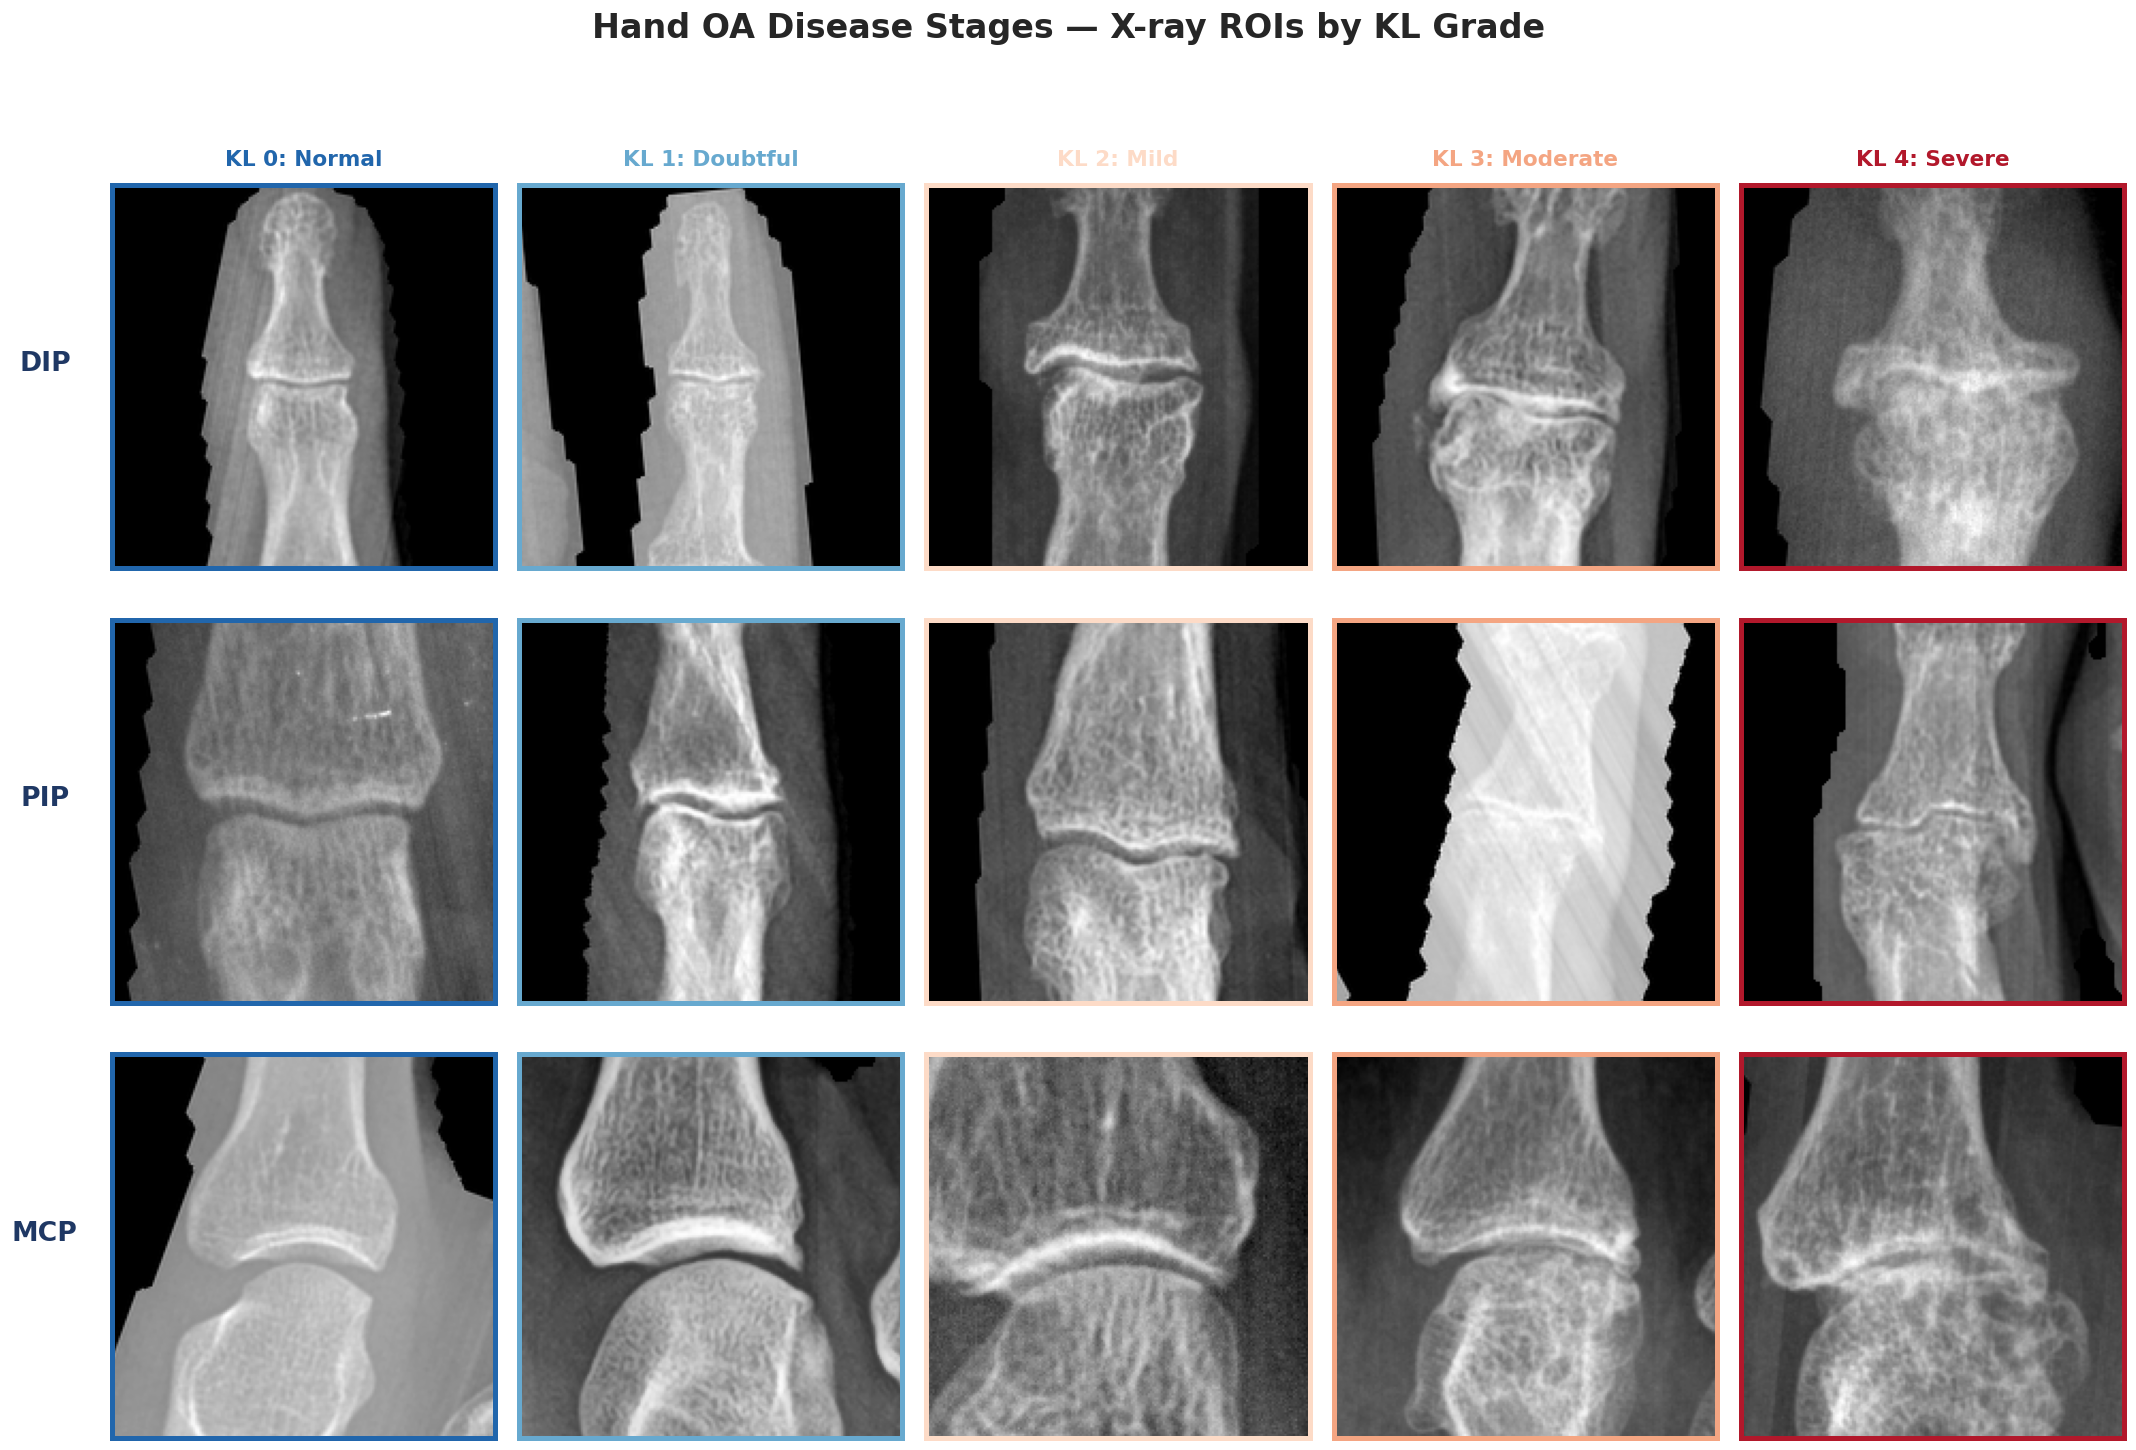

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 4 — Disease stage grid (joint type × KL grade)
# ════════════════════════════════════════════════════════

KL_LABELS = {0: 'Normal', 1: 'Doubtful', 2: 'Mild', 3: 'Moderate', 4: 'Severe'}
KL_COLORS = {0: '#2166ac', 1: '#67a9cf', 2: '#fddbc7', 3: '#f4a582', 4: '#b2182b'}
JT_ORDER = ['DIP', 'PIP', 'MCP']
KL_ORDER = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(3, 5, figsize=(18, 12))
fig.suptitle('Hand OA Disease Stages — X-ray ROIs by KL Grade',
             fontsize=20, fontweight='bold', y=1.03)

for i, jt in enumerate(JT_ORDER):
    for j, kl in enumerate(KL_ORDER):
        ax = axes[i][j]
        sub = sampled[(sampled['joint_type'] == jt) & (sampled['KL'] == kl)]

        if len(sub) > 0:
            img = mpimg.imread(sub.iloc[0]['filepath'])
            ax.imshow(img, cmap='gray')
            for spine in ax.spines.values():
                spine.set_edgecolor(KL_COLORS[kl])
                spine.set_linewidth(3)
                spine.set_visible(True)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.text(0.5, 0.5, f'No KL {kl}\nfor {jt}', ha='center',
                    va='center', fontsize=10, color='gray', transform=ax.transAxes)
            ax.set_facecolor('#f9f9f9')
            ax.axis('off')

        if i == 0:
            ax.set_title(f'KL {kl}: {KL_LABELS[kl]}', fontsize=13,
                        fontweight='bold', color=KL_COLORS[kl], pad=12)

    axes[i][0].set_ylabel(jt, fontsize=16, fontweight='bold',
                          color='#1F3864', rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

## 4. DIP Progression Strip (Multiple Examples)

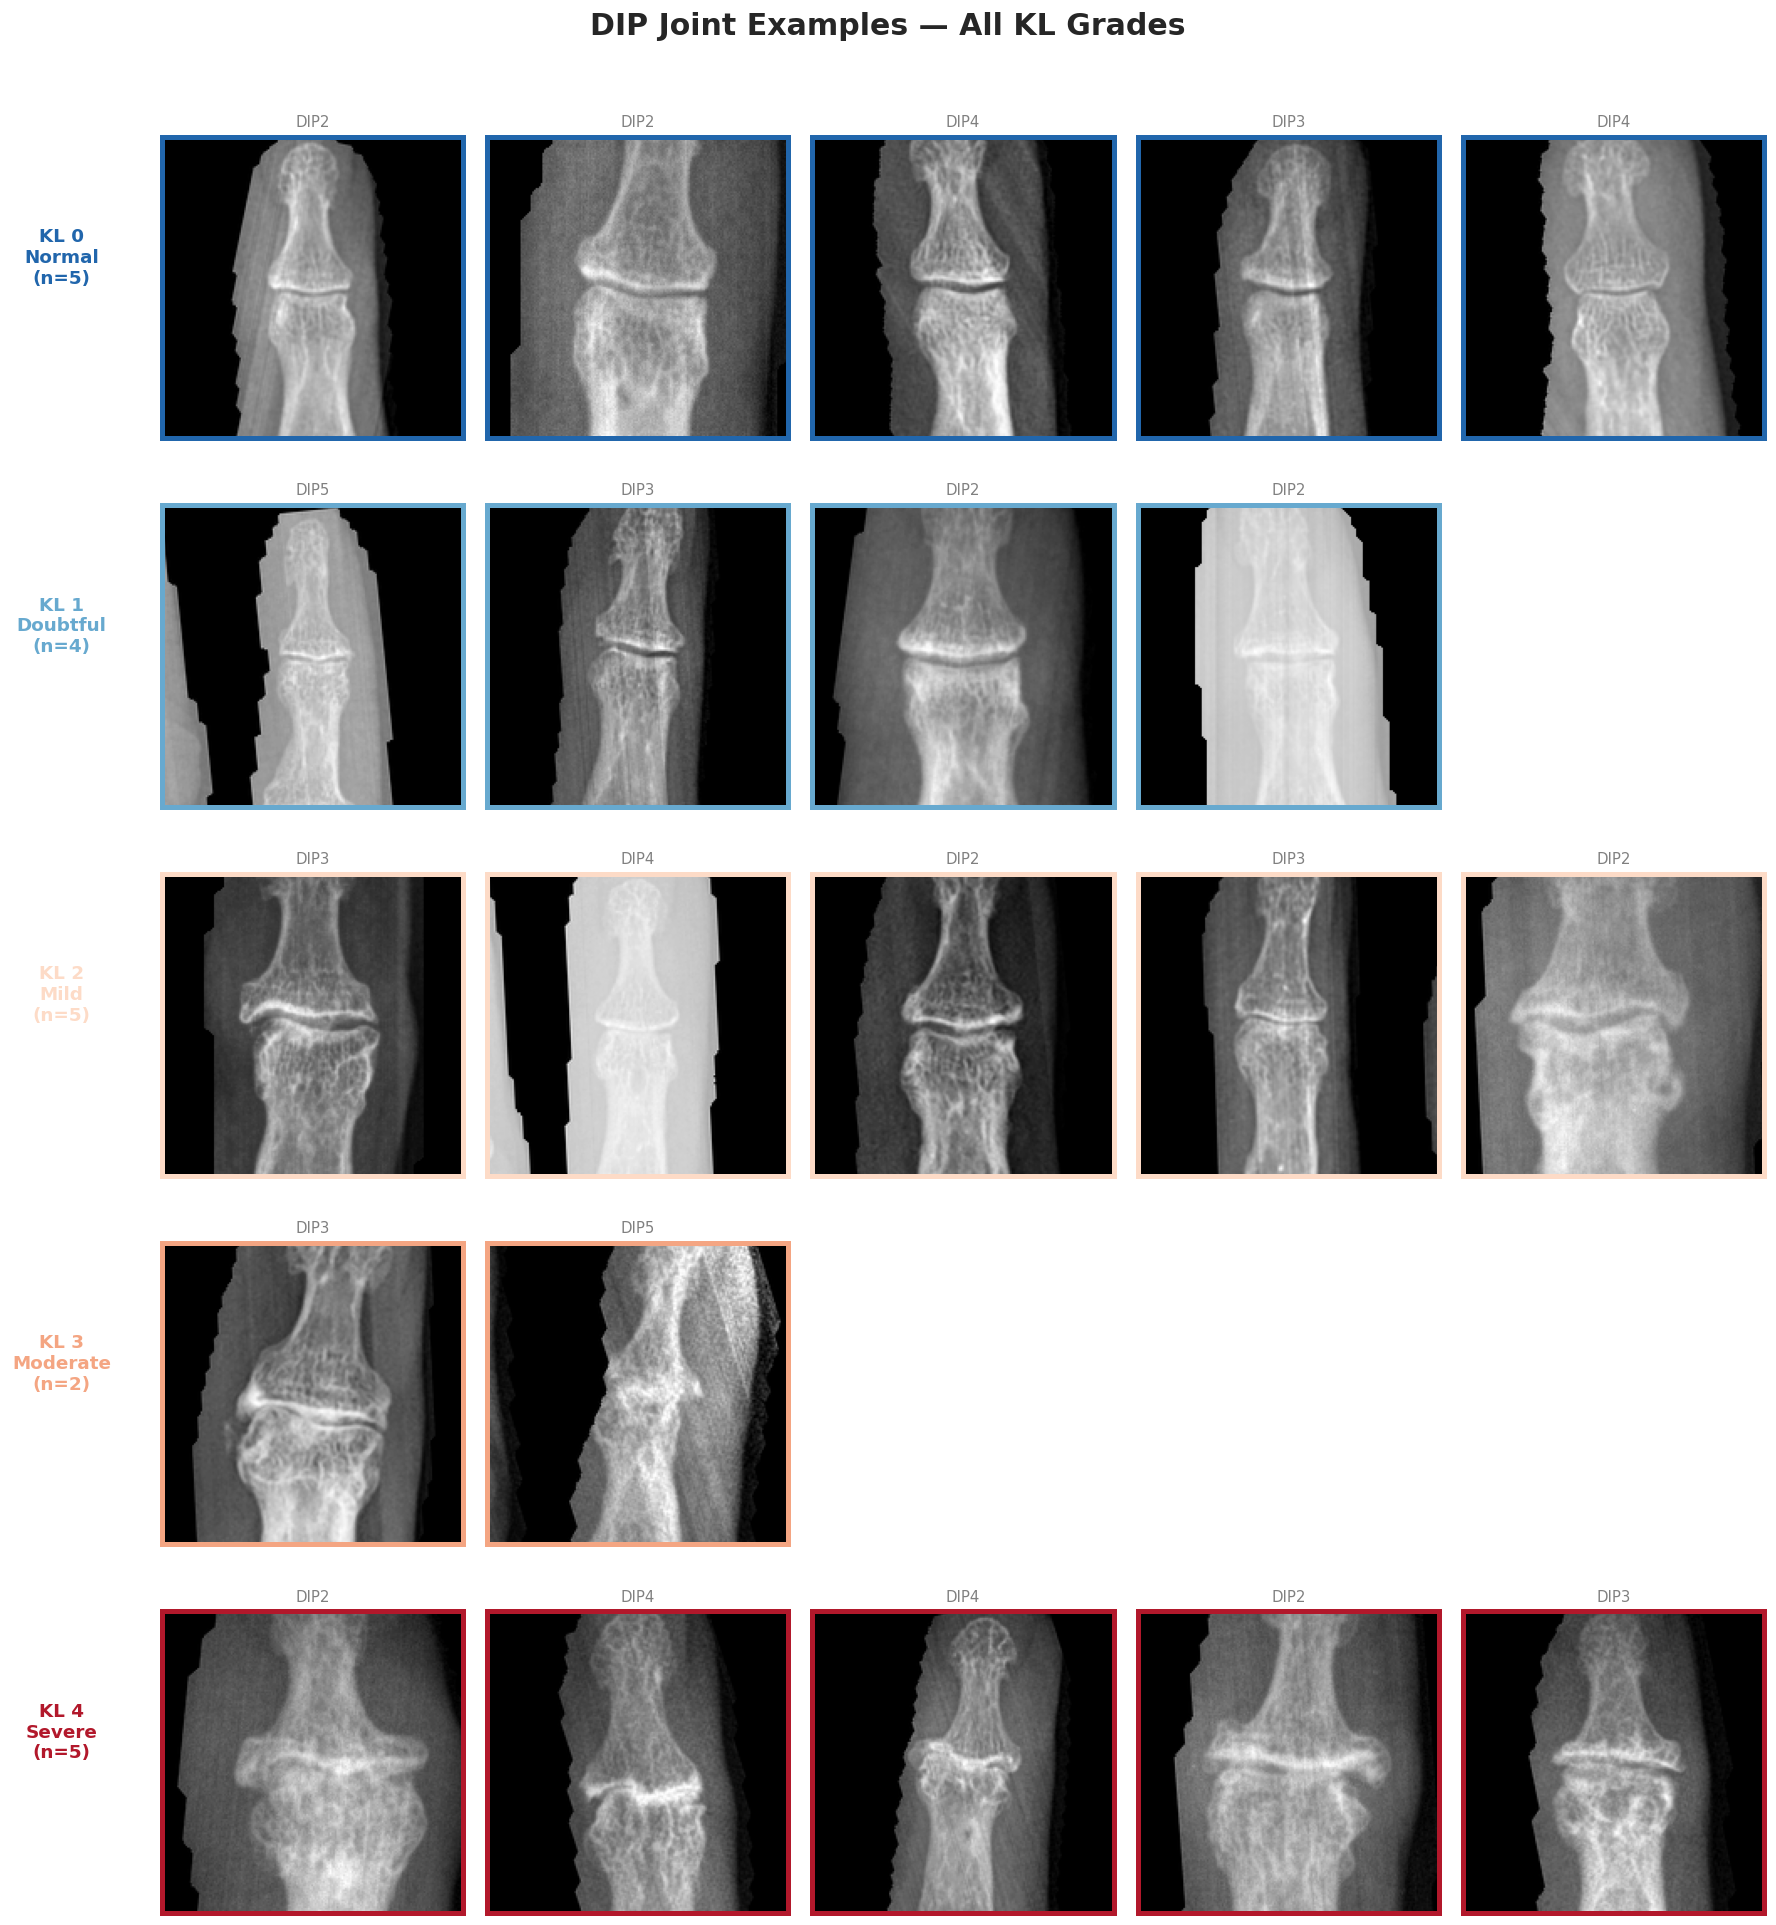

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 5 — DIP joints across KL grades (multiple examples)
# ════════════════════════════════════════════════════════

dip = sampled[sampled['joint_type'] == 'DIP']

fig, axes = plt.subplots(5, N_PER_GROUP, figsize=(3 * N_PER_GROUP, 16))
fig.suptitle('DIP Joint Examples — All KL Grades',
             fontsize=18, fontweight='bold', y=1.01)

for i, kl in enumerate(KL_ORDER):
    sub = dip[dip['KL'] == kl]
    for j in range(N_PER_GROUP):
        ax = axes[i][j]
        if j < len(sub):
            img = mpimg.imread(sub.iloc[j]['filepath'])
            ax.imshow(img, cmap='gray')
            ax.set_title(f"{sub.iloc[j]['joint']}", fontsize=9, color='gray')
            for spine in ax.spines.values():
                spine.set_edgecolor(KL_COLORS[kl])
                spine.set_linewidth(3)
                spine.set_visible(True)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis('off')

    axes[i][0].set_ylabel(f'KL {kl}\n{KL_LABELS[kl]}\n(n={len(sub)})',
                          fontsize=11, fontweight='bold',
                          color=KL_COLORS[kl], rotation=0, labelpad=60)

plt.tight_layout()
plt.show()

## 5. KL Distribution Analysis

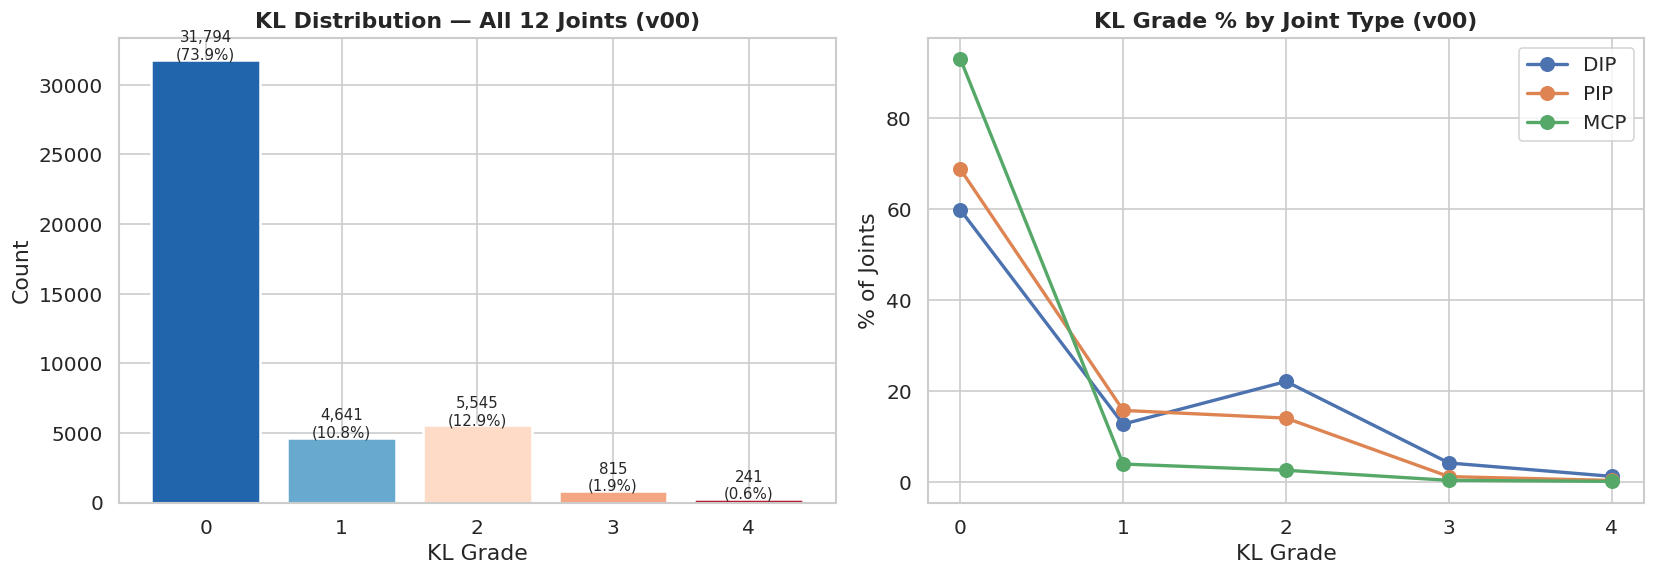

— KL Distribution by Joint Type (v00) —

  DIP (n=14,334, mean=0.74):
    KL 0: 8,575 ( 59.8%)
    KL 1: 1,821 ( 12.7%)
    KL 2: 3,165 ( 22.1%)
    KL 3:   597 (  4.2%)
    KL 4:   176 (  1.2%)

  PIP (n=14,344, mean=0.49):
    KL 0: 9,862 ( 68.8%)
    KL 1: 2,255 ( 15.7%)
    KL 2: 2,012 ( 14.0%)
    KL 3:   168 (  1.2%)
    KL 4:    47 (  0.3%)

  MCP (n=14,358, mean=0.11):
    KL 0: 13,357 ( 93.0%)
    KL 1:   565 (  3.9%)
    KL 2:   368 (  2.6%)
    KL 3:    50 (  0.3%)
    KL 4:    18 (  0.1%)


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 6 — KL distribution: overall + by joint type
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall KL
kl_counts = v00['KL'].value_counts().sort_index()
colors = [KL_COLORS[k] for k in kl_counts.index]
bars = axes[0].bar(kl_counts.index.astype(str), kl_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, kl_counts.values):
    pct = val / kl_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('KL Distribution — All 12 Joints (v00)', fontweight='bold')
axes[0].set_xlabel('KL Grade'); axes[0].set_ylabel('Count')

# By joint type
for jt in JT_ORDER:
    sub = v00[v00['joint_type'] == jt]
    kl_pct = sub['KL'].value_counts(normalize=True).sort_index() * 100
    axes[1].plot(kl_pct.index, kl_pct.values, 'o-', label=jt, linewidth=2, markersize=8)
axes[1].set_title('KL Grade % by Joint Type (v00)', fontweight='bold')
axes[1].set_xlabel('KL Grade'); axes[1].set_ylabel('% of Joints')
axes[1].legend(fontsize=12); axes[1].set_xticks([0,1,2,3,4])

plt.tight_layout(); plt.show()

# Numeric breakdown
print("— KL Distribution by Joint Type (v00) —")
for jt in JT_ORDER:
    sub = v00[v00['joint_type'] == jt]['KL']
    counts = sub.value_counts().sort_index()
    total = counts.sum()
    print(f"\n  {jt} (n={total:,}, mean={sub.mean():.2f}):")
    for grade, count in counts.items():
        print(f"    KL {grade}: {count:5,} ({count/total*100:5.1f}%)")

## 6. All Score Distributions + Correlations

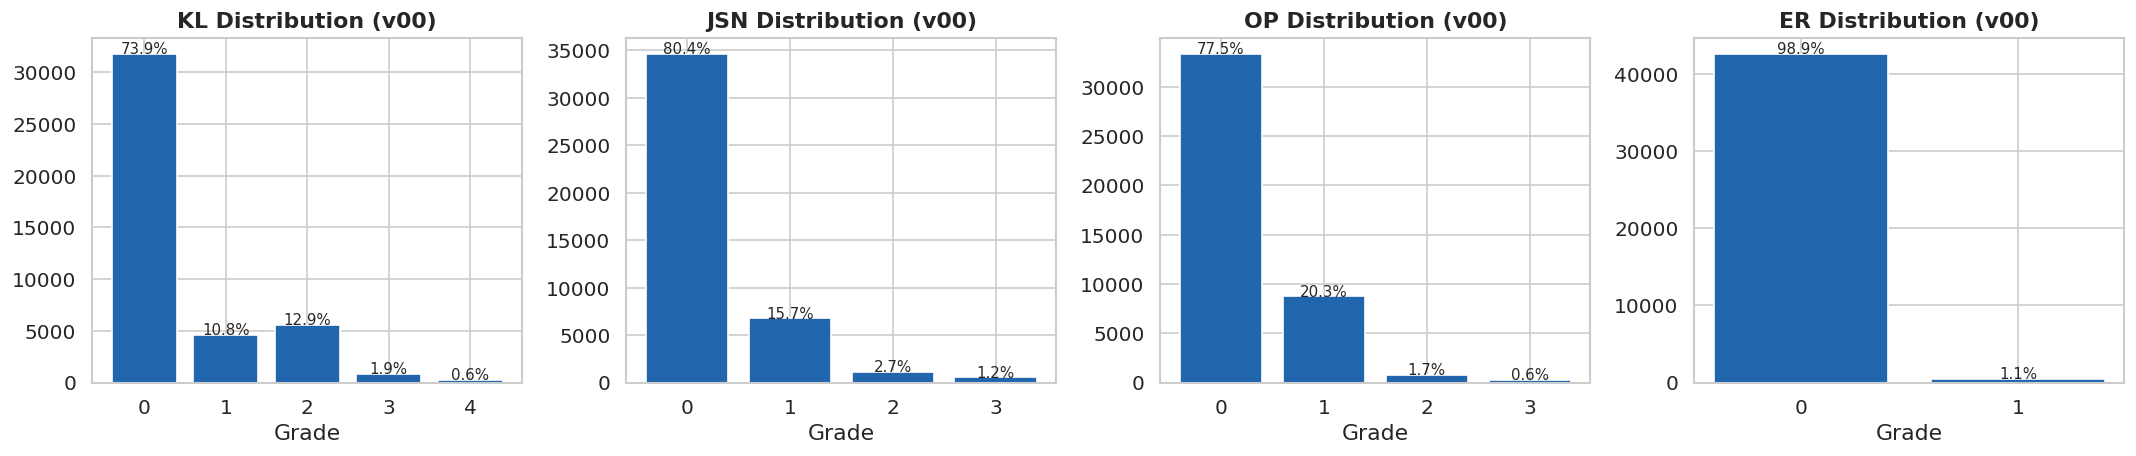

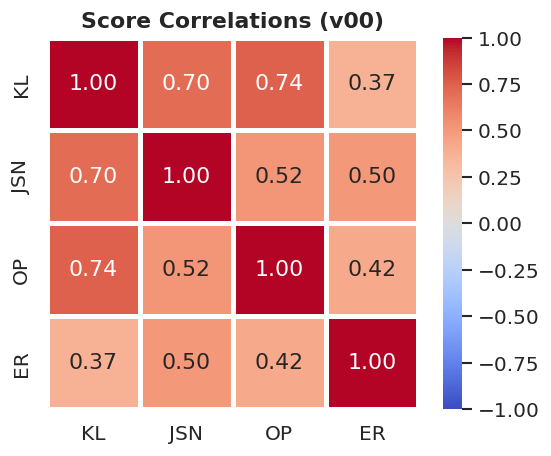

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 7 — JSN, OP, ER distributions + score correlation
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, score in zip(axes, SCORES):
    data = v00[score].dropna()
    counts = data.value_counts().sort_index()
    ax.bar(counts.index.astype(int).astype(str), counts.values,
           color='#2166ac', edgecolor='white')
    for bar, val in zip(ax.patches, counts.values):
        pct = val / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{pct:.1f}%', ha='center', fontsize=9)
    ax.set_title(f'{score} Distribution (v00)', fontweight='bold')
    ax.set_xlabel('Grade')

plt.tight_layout(); plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
corr = v00[SCORES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, vmin=-1, vmax=1, linewidths=2, linecolor='white')
ax.set_title('Score Correlations (v00)', fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Disease Progression (v00 → v06)

Patients with v00 only:  0
Patients with v06 only:  0
Patients with BOTH:      3,588


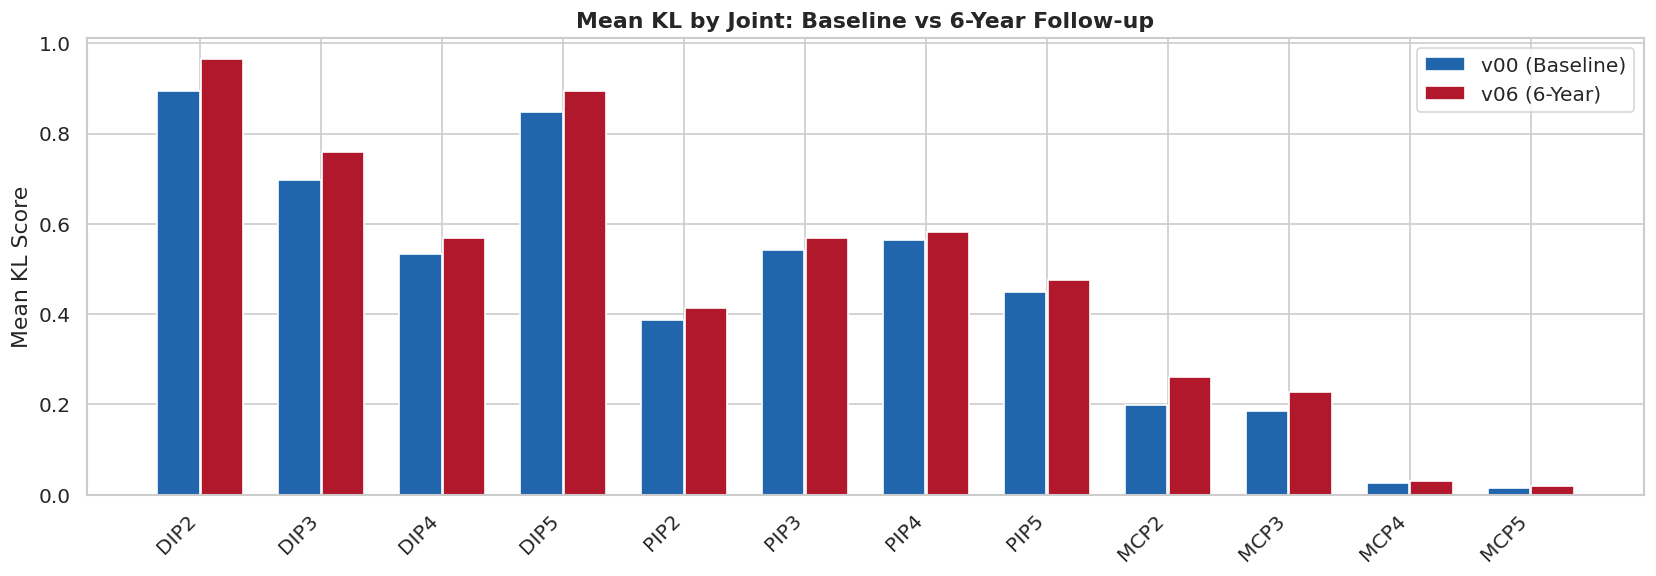

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 8 — Baseline vs 6-year follow-up
# ════════════════════════════════════════════════════════

pts_v00 = set(v00['patient_id'].unique())
pts_v06 = set(v06['patient_id'].unique())
pts_both = pts_v00 & pts_v06

print(f"Patients with v00 only:  {len(pts_v00 - pts_v06):,}")
print(f"Patients with v06 only:  {len(pts_v06 - pts_v00):,}")
print(f"Patients with BOTH:      {len(pts_both):,}")

joints = IMAGE_JOINTS
v00_means = [v00[v00['joint'] == j]['KL'].mean() for j in joints]
v06_means = [v06[v06['joint'] == j]['KL'].mean() for j in joints]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(joints))
ax.bar(x - 0.18, v00_means, 0.35, label='v00 (Baseline)', color='#2166ac', edgecolor='white')
ax.bar(x + 0.18, v06_means, 0.35, label='v06 (6-Year)', color='#b2182b', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(joints, rotation=45, ha='right')
ax.set_title('Mean KL by Joint: Baseline vs 6-Year Follow-up', fontweight='bold')
ax.set_ylabel('Mean KL Score'); ax.legend()
plt.tight_layout(); plt.show()

## 8. Mean KL per Joint + OA Prevalence

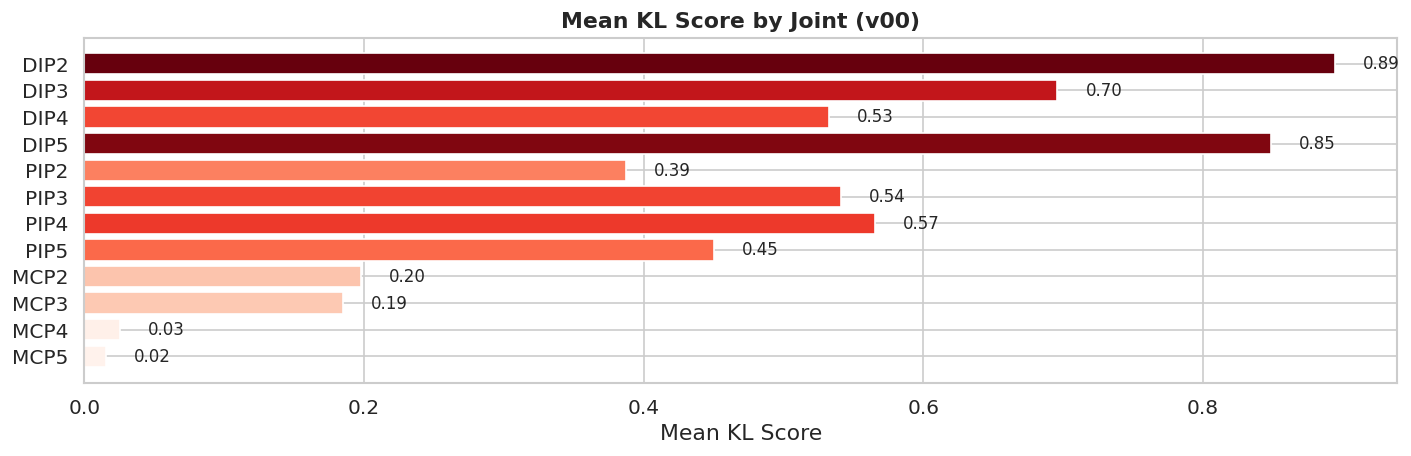

— Patient-Level Max KL (v00) —
  Max KL 0: 837 patients (23.3%)
  Max KL 1: 857 patients (23.9%)
  Max KL 2: 1,420 patients (39.6%)
  Max KL 3: 358 patients (10.0%)
  Max KL 4: 116 patients (3.2%)

  Any OA (KL≥2): 52.8% of patients


In [ ]:
# ════════════════════════════════════════════════════════
# CELL 9 — Per-joint severity + patient-level OA
# ════════════════════════════════════════════════════════

mean_kl = v00.groupby('joint')['KL'].mean().reindex(IMAGE_JOINTS)

fig, ax = plt.subplots(figsize=(12, 4))
colors_bar = plt.cm.Reds(mean_kl / mean_kl.max())
bars = ax.barh(mean_kl.index, mean_kl.values, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, mean_kl.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlabel('Mean KL Score')
ax.set_title('Mean KL Score by Joint (v00)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Patient-level
patient_max_kl = v00.groupby('patient_id')['KL'].max()
pct_oa = (patient_max_kl >= 2).sum() / len(patient_max_kl) * 100

print("— Patient-Level Max KL (v00) —")
for grade in sorted(patient_max_kl.dropna().unique()):
    n = (patient_max_kl == grade).sum()
    print(f"  Max KL {int(grade)}: {n:,} patients ({n/len(patient_max_kl)*100:.1f}%)")
print(f"\n  Any OA (KL≥2): {pct_oa:.1f}% of patients")

## 9. Summary Report

In [ ]:
# ════════════════════════════════════════════════════════
# CELL 10 — Final summary
# ════════════════════════════════════════════════════════

dip_mean = v00[v00['joint_type'] == 'DIP']['KL'].mean()
mcp_mean = v00[v00['joint_type'] == 'MCP']['KL'].mean()
missing_total = df.isnull().sum().sum()
missing_pct = missing_total / (df.shape[0] * df.shape[1]) * 100
severe_count = (v00['KL'] >= 3).sum()
total_joints = len(v00)

print("=" * 65)
print("  CS 790 — DATASET STATISTICAL ANALYSIS REPORT")
print("=" * 65)

print(f"""
1. IMAGE DATABASE
   Total ROI images:      41,061
   Median dimensions:     180 x 180 px
   Joint types:           DIP(2-5), PIP(2-5), MCP(2-5) = 12/hand
   Total size:            ~654 MB

2. CLINICAL DATA
   Patients:              {df.shape[0]:,}
   Columns:               {df.shape[1]} (wide format)
   Timepoints:            v00 (baseline) + v06 (6-year)
   Missing values:        {missing_total:,} ({missing_pct:.1f}%)

3. KL DISTRIBUTION (v00, all 12 joints)
""")

kl_all = v00['KL'].value_counts().sort_index()
total = kl_all.sum()
for grade, count in kl_all.items():
    bar = "█" * int(count / total * 50)
    print(f"   KL {grade}: {count:6,} ({count/total*100:5.1f}%)  {bar}")

print(f"""
4. KEY FINDINGS
   - DIP most affected (mean KL = {dip_mean:.2f})
   - MCP least affected (mean KL = {mcp_mean:.2f})
   - KL 3+4 = {severe_count}/{total} ({severe_count/total*100:.1f}%) — severe is rare
   - {len(pts_both):,} patients have both timepoints
   - Disease progression confirmed v00 → v06
""")
print("=" * 65)

  CS 790 — DATASET STATISTICAL ANALYSIS REPORT

1. IMAGE DATABASE
   Total ROI images:      41,061
   Median dimensions:     180 x 180 px
   Joint types:           DIP(2-5), PIP(2-5), MCP(2-5) = 12/hand
   Total size:            ~654 MB

2. CLINICAL DATA
   Patients:              3,590
   Columns:               275 (wide format)
   Timepoints:            v00 (baseline) + v06 (6-year)
   Missing values:        51,290 (5.2%)

3. KL DISTRIBUTION (v00, all 12 joints)

   KL 0: 31,794 ( 73.9%)  ████████████████████████████████████
   KL 1:  4,641 ( 10.8%)  █████
   KL 2:  5,545 ( 12.9%)  ██████
   KL 3:    815 (  1.9%)  
   KL 4:    241 (  0.6%)  

4. KEY FINDINGS
   - DIP most affected (mean KL = 0.74)
   - MCP least affected (mean KL = 0.11)
   - KL 3+4 = 1056/43036 (2.5%) — severe is rare
   - 3,588 patients have both timepoints
   - Disease progression confirmed v00 → v06



In [ ]:
# What do the actual filenames in the zip look like?
import zipfile

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    sample_names = [os.path.basename(n) for n in zf.namelist() if n.endswith('.png')][:10]

print("Filenames in zip:")
for n in sorted(sample_names):
    print(f"  {n}")

# What IDs are in the spreadsheet?
print(f"\nSample 'id' values:      {df['id'].dropna().head(5).tolist()}")
print(f"Sample 'duryeaid' values: {df['duryeaid'].dropna().head(5).tolist()}")

# Compare formats
sample_file_id = sample_names[0].rsplit('_', 1)[0]
print(f"\nID from filename: '{sample_file_id}' (len={len(sample_file_id)})")
print(f"ID from Excel:    '{str(int(df['id'].iloc[0]))}' (len={len(str(int(df['id'].iloc[0])))})")

Filenames in zip:
  9000099_dip2.png
  9000099_dip3.png
  9000099_dip4.png
  9000099_dip5.png
  9000099_mcp2.png
  9000099_mcp3.png
  9000099_mcp4.png
  9000099_mcp5.png
  9000099_pip2.png
  9000099_pip3.png

Sample 'id' values:      [9000099, 9000296, 9000798, 9001695, 9001897]
Sample 'duryeaid' values: [15937, 17642, 17546, 13378, 12451]

ID from filename: '9000099' (len=7)
ID from Excel:    '9000099' (len=7)
